# 11. Multi-Scale CNN Classification on VMD Features
**Objective:** Evaluate if feeding purely physical Intrinsic Mode Functions (IMFs) into a multi-resolution deep learning architecture bridges the gap toward state-of-the-art accuracy.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sys.path.append(os.path.abspath('../'))
from src.config import PREPROCESSED_DIR, DEVICE
from src.vmd_net import MultiScaleVMDNet, train_vmd_model

plt.style.use('seaborn-v0_8-whitegrid')

### 1. Load Serialized VMD Features (Subject 1)

In [2]:
vmd_h5_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1_VMD.h5")
with h5py.File(vmd_h5_path, 'r') as f:
    X_vmd = np.array(f['X_vmd'])
    y_bal = np.array(f['y']).astype(np.int64)
    reps_bal = np.array(f['reps'])

print(f"Loaded VMD Tensor Shape: {X_vmd.shape}")

# Training Repetitions: 1-7, Testing Repetitions: 8-10
train_reps = [1, 2, 3, 4, 5, 6, 7]
test_reps = [8, 9, 10]

train_idx = np.where(np.isin(reps_bal, train_reps))[0]
test_idx = np.where(np.isin(reps_bal, test_reps))[0]

X_train = X_vmd[train_idx]
y_train = y_bal[train_idx]

X_test = X_vmd[test_idx]
y_test = y_bal[test_idx]

print(f"Training Windows: {X_train.shape[0]}")
print(f"Testing Windows: {X_test.shape[0]}")

Loaded VMD Tensor Shape: (18630, 3, 20, 10)
Training Windows: 12664
Testing Windows: 5444


### 2. Initialize & Train Multi-Scale VMD Network

In [3]:
num_classes = int(max(y_train.max(), y_test.max()) + 1)

vmd_model = MultiScaleVMDNet(num_classes=num_classes)

vmd_model = train_vmd_model(
    model=vmd_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    epochs=50, # Slightly longer training for deeper network
    batch_size=64,
    lr=0.001
)

Training VMD Multi-Scale Network on cuda...
Epoch 1/50 | Loss: 3.8133
Epoch 5/50 | Loss: 3.2614
Epoch 10/50 | Loss: 2.9557
Epoch 15/50 | Loss: 2.7777
Epoch 20/50 | Loss: 2.6677
Epoch 25/50 | Loss: 2.5853
Epoch 30/50 | Loss: 2.5158
Epoch 35/50 | Loss: 2.4575
Epoch 40/50 | Loss: 2.4232
Epoch 45/50 | Loss: 2.3856
Epoch 50/50 | Loss: 2.3370


### 3. Evaluate Network Performance

In [4]:
vmd_model.eval()
with torch.no_grad():
    X_te_tensor = torch.FloatTensor(X_test).to(DEVICE)
    raw_outputs = vmd_model(X_te_tensor)
    vmd_preds = torch.argmax(raw_outputs, dim=1).cpu().numpy()

vmd_acc = accuracy_score(y_test, vmd_preds)
vmd_f1 = f1_score(y_test, vmd_preds, average='macro')

print("\n--- Multi-Scale VMD Network Results ---")
print(f"Accuracy: {vmd_acc * 100:.2f}%")
print(f"Macro F1-Score: {vmd_f1 * 100:.2f}%")


--- Multi-Scale VMD Network Results ---
Accuracy: 34.04%
Macro F1-Score: 32.36%


### 4. Confusion Matrix Analysis

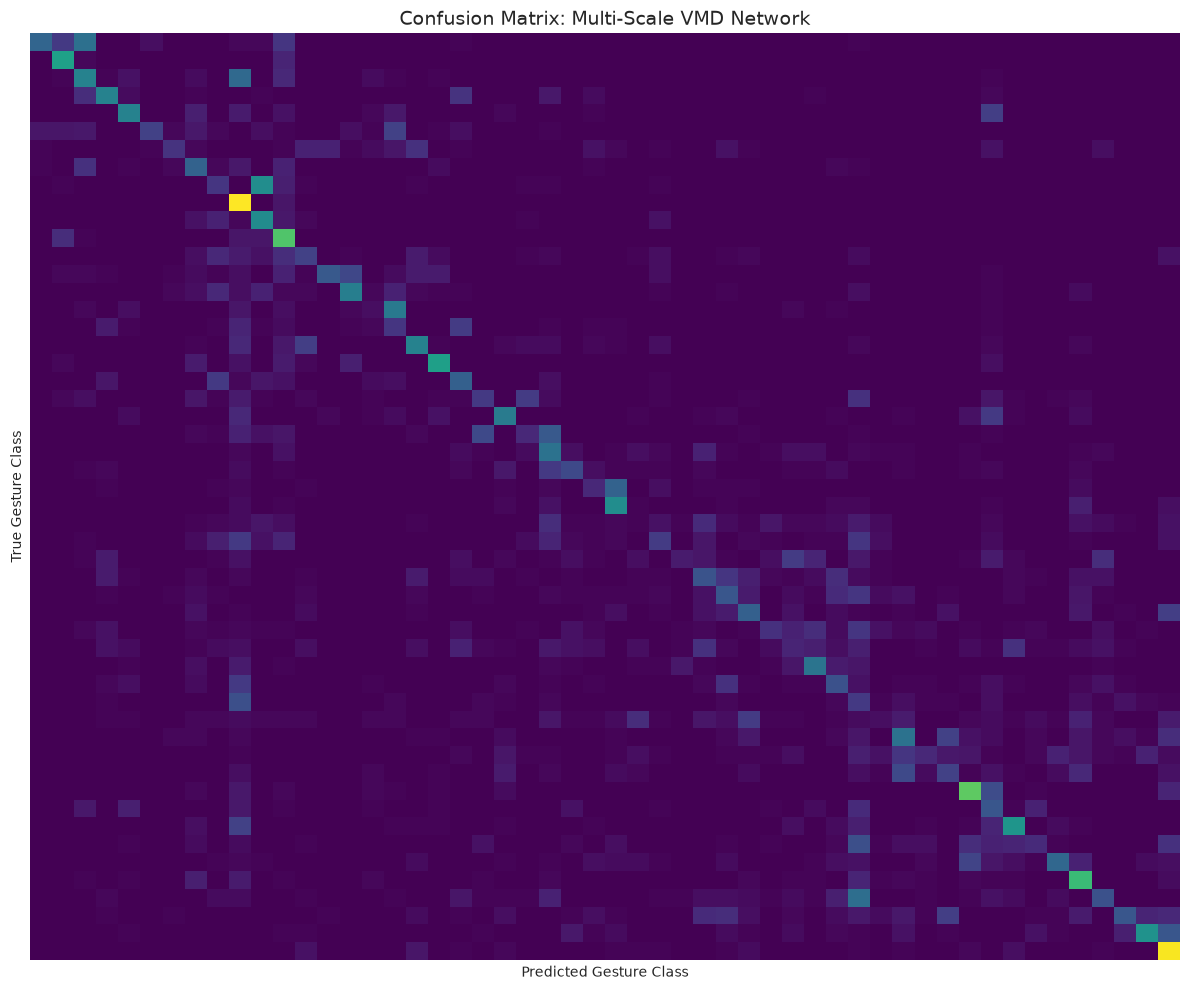

In [5]:
conf_matrix = confusion_matrix(y_test, vmd_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, cmap='viridis', cbar=False, xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix: Multi-Scale VMD Network", fontsize=14)
plt.xlabel("Predicted Gesture Class")
plt.ylabel("True Gesture Class")
plt.tight_layout()
plt.show()